In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load master dataset
master_df = pd.read_csv("../outputs/master_customer_table.csv")

# Convert timestamp
master_df["order_purchase_timestamp"] = pd.to_datetime(
    master_df["order_purchase_timestamp"]
)

master_df.head()

,customer_unique_id,order_id,order_purchase_timestamp,order_status,product_id,price,review_score,review_comment_message,product_category_name
0,861eff4711a542e4b93843c6dd7febb0,00e7ee1b050b8499577073aeb2a297a1,2017-05-16 15:05:35,delivered,a9516a079e37a9c9c36b9b78b10169e8,124.99,4.0,NaN,moveis_escritorio
1,290c77bc529b7ac935b93aa66c333dc3,29150127e6685892b6eab3eec79f59c7,2018-01-12 20:48:24,delivered,4aa6014eceb682077f9dc4bffebc05b0,289.00,5.0,NaN,utilidades_domesticas
2,060e732b5b29e8181a18229c7b0b2b5e,b2059ed67ce144a36e2aa97d2c9e9ad2,2018-05-19 16:07:45,delivered,bd07b66896d6f1494f5b86251848ced7,139.94,5.0,NaN,moveis_escritorio
3,259dac757896d24d7702b9acbbff3f3c,951670f92359f4fe4a63112aa7306eba,2018-03-13 16:06:38,delivered,a5647c44af977b148e0a3a4751a09e2e,149.94,5.0,NaN,moveis_escritorio
4,345ecd01c38d18a9036ed96c73b8d066,6b7d50bd145f6fc7f33cebabd7e49d0f,2018-07-29 09:51:30,delivered,9391a573abe00141c56e38d84d7d5b3b,230.00,5.0,O baratheon è esxelente Amo adoro o baratheon,casa_conforto


In [2]:
# Define reference date (latest order date)
reference_date = master_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    master_df
    .groupby("customer_unique_id")
    .agg({
        "order_purchase_timestamp": lambda x: (reference_date - x.max()).days,
        "order_id": "nunique",
        "price": "sum"
    })
    .reset_index()
)

rfm.columns = ["customer_unique_id", "recency", "frequency", "monetary"]

rfm.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,18.90
2,0000f46a3911fa3c0805444483337064,542,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,293,1,180.00


In [3]:
rfm.describe()

,recency,frequency,monetary
count,95420.000000,95420.000000,95420.000000
mean,243.600377,1.034018,143.071929
std,153.160320,0.211234,218.878967
min,1.000000,1.000000,0.850000
25%,119.000000,1.000000,47.900000
50%,224.000000,1.000000,89.900000
75%,353.000000,1.000000,155.990000
max,729.000000,16.000000,13440.000000


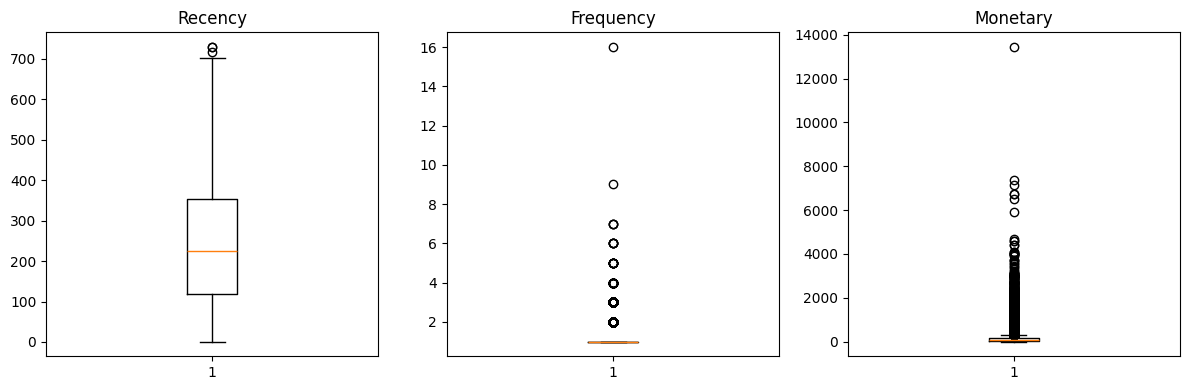

In [4]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.boxplot(rfm["recency"])
plt.title("Recency")

plt.subplot(1, 3, 2)
plt.boxplot(rfm["frequency"])
plt.title("Frequency")

plt.subplot(1, 3, 3)
plt.boxplot(rfm["monetary"])
plt.title("Monetary")

plt.tight_layout()
plt.show()

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

rfm_scaled = rfm.copy()
rfm_scaled[["recency", "frequency", "monetary"]] = scaler.fit_transform(
    rfm_scaled[["recency", "frequency", "monetary"]]
)

rfm_scaled.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,0.157967,0.0,0.009603
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.162088,0.0,0.001343
2,0000f46a3911fa3c0805444483337064,0.743132,0.0,0.005071
3,0000f6ccb0745a6a4b88665a16c9f078,0.446429,0.0,0.001871
4,0004aac84e0df4da2b147fca70cf8255,0.401099,0.0,0.013330


In [6]:
rfm.to_csv("../outputs/rfm_raw.csv", index=False)
rfm_scaled.to_csv("../outputs/rfm_scaled.csv", index=False)

print("RFM raw and scaled files saved.")

RFM raw and scaled files saved.
